# Train HeatGeo from GitHub (Colab)

In [6]:
#@title 1. Cấu hình experiment
REPO_URL = "https://github.com/Savoxism/embedding-kd.git"
BRANCH = "nqd_mass_geom_loss"

PAIR_KEY = "bge_m3_to_minilmv2_h768" #@param
# ["qwen3_0_6b_to_minilmv2_h384", "bge_m3_to_minilmv2_h768", "qwen3_4b_to_bert_base"]

# Bề mặt hyperparam sau đợt thu gọn:
# - diffusion_quota: DERIVED từ graph artifact (coverage tau=0.7, policy.py) —
#   không còn là knob; log in "Derived diffusion_quota=..." mỗi run.
# - deterministic_topm: policy constant; direct_temp: default 0.1 (đo được flat).
# - hard_neg_k/random_neg_k, learning_rate: default config = arm thắng (40/26, 3e-5).
# Muốn ablation knob nào thì truyền qua EXTRA_ARGS và đổi RUN_NAME.
ROW_WEIGHT = 1.0 #@param {type:"number"}
ROW_START_EPOCH = 1 #@param {type:"integer"}

RUN_NAME = "row_loss_run" #@param {type:"string"}

BATCH_SIZE = 64 #@param {type:"integer"}
EPOCHS = 5 #@param {type:"integer"}
LEARNING_RATE = 3e-5 #@param {type:"number"}
MAX_LENGTH = 256 #@param {type:"integer"}
SEED = 42 #@param {type:"integer"}
NUM_WORKERS = 4 #@param {type:"integer"}
TRAIN_DATA = "data/train_set/merged_3_data_5k_each.csv" #@param {type:"string"}

FINAL_WEIGHTS_ONLY = True #@param {type:"boolean"}
REQUIRE_GPU = True #@param {type:"boolean"}

USE_GOOGLE_DRIVE = False #@param {type:"boolean"}
DRIVE_ROOT = "/content/drive/MyDrive/embedding-kd-runs" #@param {type:"string"}

# Thêm CLI flags nếu cần, ví dụ: --diffusion_quota 44 --hard_neg_k 26
# Chú ý: knob trong EXTRA_ARGS KHÔNG vào RUN_TAG — arm dùng EXTRA_ARGS phải đổi
# RUN_NAME để không ghi đè.
EXTRA_ARGS = "" #@param {type:"string"}

assert ROW_WEIGHT >= 0, "ROW_WEIGHT phải không âm"
assert ROW_START_EPOCH >= 1, "ROW_START_EPOCH phải bắt đầu từ 1"
assert BATCH_SIZE > 0 and EPOCHS > 0 and MAX_LENGTH > 0

# Mỗi arm ghi vào thư mục riêng để các run không đè lên nhau. "qauto" đánh dấu
# quota derived và tách thư mục khỏi các run cũ dùng quota chỉnh tay.
RUN_TAG = (
    f"{RUN_NAME}_w{ROW_WEIGHT:g}_e{ROW_START_EPOCH}"
    f"_qauto_lr{LEARNING_RATE:g}_seed{SEED}"
)


In [7]:
# 2. Clone lần đầu; các lần Run all sau luôn fetch/reset/pull branch mới nhất
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/embedding-kd")

def git(*args):
    command = ["git", "-C", str(REPO_DIR), *args]
    print("+", " ".join(command))
    subprocess.run(command, check=True)

if (REPO_DIR / ".git").is_dir():
    git("remote", "set-url", "origin", REPO_URL)
    # Bỏ thay đổi tracked trong clone Colab để luôn checkout được remote head.
    git("reset", "--hard")
    git("fetch", "--prune", "origin")
    git("checkout", "-B", BRANCH, f"origin/{BRANCH}")
    git("reset", "--hard", f"origin/{BRANCH}")
    git("pull", "--ff-only", "origin", BRANCH)
elif REPO_DIR.exists() and any(REPO_DIR.iterdir()):
    raise RuntimeError(f"{REPO_DIR} tồn tại nhưng không phải Git repository")
else:
    subprocess.run(
        ["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, str(REPO_DIR)],
        check=True,
    )

commit = subprocess.check_output(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True
).strip()
print(f"Ready: {BRANCH}@{commit[:12]}")


+ git -C /content/embedding-kd remote set-url origin https://github.com/Savoxism/embedding-kd.git
+ git -C /content/embedding-kd reset --hard
+ git -C /content/embedding-kd fetch --prune origin
+ git -C /content/embedding-kd checkout -B nqd_mass_geom_loss origin/nqd_mass_geom_loss
+ git -C /content/embedding-kd reset --hard origin/nqd_mass_geom_loss
+ git -C /content/embedding-kd pull --ff-only origin nqd_mass_geom_loss
Ready: nqd_mass_geom_loss@e5880e6ba522


In [8]:
# 3. Cài/đồng bộ dependencies theo code vừa pull
import os
import sys

os.chdir(REPO_DIR)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_DIR / "requirements.txt")],
    check=True,
)
print("Dependencies are ready.")


Dependencies are ready.


In [9]:
# 4. Resolve model pair, GPU và nơi lưu artifacts
import torch

PAIR_CONFIGS = {
    "qwen3_0_6b_to_minilmv2_h384": {
        "teacher": "Qwen/Qwen3-Embedding-0.6B",
        "student": "nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base",
        "pooling": "last_token",
    },
    "bge_m3_to_minilmv2_h768": {
        "teacher": "BAAI/bge-m3",
        "student": "nreimers/MiniLMv2-L6-H768-distilled-from-BERT-Base",
        "pooling": "cls",
    },
    "qwen3_4b_to_bert_base": {
        "teacher": "Qwen/Qwen3-Embedding-4B",
        "student": "google-bert/bert-base-uncased",
        "pooling": "last_token",
    },
}
pair = PAIR_CONFIGS[PAIR_KEY]

if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("Không tìm thấy CUDA GPU. Trong Colab chọn Runtime → Change runtime type → GPU.")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 2**30
    print(f"GPU: {props.name} ({vram_gb:.1f} GiB)")
    if PAIR_KEY == "qwen3_4b_to_bert_base" and vram_gb < 35:
        print("WARNING: Qwen3-4B ở cấu hình hiện tại có thể OOM trên GPU dưới khoảng 35 GiB.")

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    artifact_root = Path(DRIVE_ROOT)
else:
    artifact_root = REPO_DIR

# cache_dir không mang RUN_TAG: teacher embeddings và HeatGeo graph không phụ
# thuộc row mode, nên ba variant dùng chung một cache và chỉ build graph một lần.
cache_dir = artifact_root / "cache" / "heatgeo" / PAIR_KEY
log_dir = artifact_root / "logs" / "heatgeo" / PAIR_KEY
save_dir = artifact_root / "models" / "heatgeo" / PAIR_KEY / RUN_TAG
weights_dir = artifact_root / "models" / "heatgeo_weights" / PAIR_KEY / RUN_TAG
for path in (cache_dir, log_dir, save_dir, weights_dir):
    path.mkdir(parents=True, exist_ok=True)

print(f"Teacher: {pair['teacher']}")
print(f"Student: {pair['student']}")
print(f"Pooling: {pair['pooling']}")
print(f"Objective: L_rel + {ROW_WEIGHT} * L_row")
print(f"Row starts at epoch: {ROW_START_EPOCH}")
print(f"Outputs: {save_dir}")


GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GiB)
Teacher: BAAI/bge-m3
Student: nreimers/MiniLMv2-L6-H768-distilled-from-BERT-Base
Pooling: cls
Objective: L_rel + 1.0 * L_row
Row starts at epoch: 1
Outputs: /content/embedding-kd/models/heatgeo/bge_m3_to_minilmv2_h768/row_loss_run_w1_e1_qauto_lr3e-05_seed42


In [10]:
# 5. Train HeatGeo
import shlex

command = [
    sys.executable, "main.py",
    "--method", "heatgeo",
    "--train_data", TRAIN_DATA,
    "--student_model", pair["student"],
    "--teacher_model", pair["teacher"],
    "--pooling_method", pair["pooling"],
    "--row_weight", str(ROW_WEIGHT),
    "--row_start_epoch", str(ROW_START_EPOCH),
    "--batch_size", str(BATCH_SIZE),
    "--epochs", str(EPOCHS),
    "--lr", str(LEARNING_RATE),
    "--max_length", str(MAX_LENGTH),
    "--seed", str(SEED),
    "--num_workers", str(NUM_WORKERS),
    "--cache_path", str(cache_dir / "teacher_train.pt"),
    "--heatgeo_cache_path", str(cache_dir / "graph.pt"),
    "--heatgeo_log_dir", str(log_dir),
    "--save_dir", str(save_dir),
    "--weights_dir", str(weights_dir),
]
if FINAL_WEIGHTS_ONLY:
    command.append("--final_weights_only")
if EXTRA_ARGS.strip():
    command.extend(shlex.split(EXTRA_ARGS))

env = os.environ.copy()
env["TOKENIZERS_PARALLELISM"] = "false"
env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print("+", shlex.join(command))
process = subprocess.Popen(
    command,
    cwd=REPO_DIR,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
for line in process.stdout:
    print(line, end="")
return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"Training failed with exit code {return_code}")


+ /usr/bin/python3 main.py --method heatgeo --train_data data/train_set/merged_3_data_5k_each.csv --student_model nreimers/MiniLMv2-L6-H768-distilled-from-BERT-Base --teacher_model BAAI/bge-m3 --pooling_method cls --row_weight 1.0 --row_start_epoch 1 --batch_size 64 --epochs 5 --lr 3e-05 --max_length 256 --seed 42 --num_workers 4 --cache_path /content/embedding-kd/cache/heatgeo/bge_m3_to_minilmv2_h768/teacher_train.pt --heatgeo_cache_path /content/embedding-kd/cache/heatgeo/bge_m3_to_minilmv2_h768/graph.pt --heatgeo_log_dir /content/embedding-kd/logs/heatgeo/bge_m3_to_minilmv2_h768 --save_dir /content/embedding-kd/models/heatgeo/bge_m3_to_minilmv2_h768/row_loss_run_w1_e1_qauto_lr3e-05_seed42 --weights_dir /content/embedding-kd/models/heatgeo_weights/bge_m3_to_minilmv2_h768/row_loss_run_w1_e1_qauto_lr3e-05_seed42 --final_weights_only

Configuration for HEATGEO method:
  task_type                 : pair_cls
  max_length                : 256
  batch_size                : 64
  epochs      

In [11]:
# 6. Xem artifacts và các metrics cuối
import json

print("Checkpoints:", save_dir)
print("Weights:", weights_dir)
metrics_path = save_dir / "metrics.jsonl"
if metrics_path.exists():
    records = [json.loads(line) for line in metrics_path.read_text().splitlines() if line.strip()]
    print(json.dumps(records[-1], indent=2, ensure_ascii=False) if records else "metrics.jsonl is empty")
else:
    print("Không tìm thấy metrics.jsonl")


Checkpoints: /content/embedding-kd/models/heatgeo/bge_m3_to_minilmv2_h768/row_loss_run_w1_e1_qauto_lr3e-05_seed42
Weights: /content/embedding-kd/models/heatgeo_weights/bge_m3_to_minilmv2_h768/row_loss_run_w1_e1_qauto_lr3e-05_seed42
{
  "method": "heatgeo",
  "run_id": "20260831-153748-77b9f1",
  "seed": 42,
  "test": {
    "avg": 77.05,
    "avg_in": 70.2,
    "avg_out": 80.48,
    "classification": {
      "data/test_set/banking77_test.csv": {
        "accuracy": 0.9063719115734721,
        "f1": 0.9062934975407558
      },
      "data/test_set/emotion_test.csv": {
        "accuracy": 0.7361530715005036,
        "f1": 0.6680828686741553
      },
      "data/test_set/tweet_test.csv": {
        "accuracy": 0.7223193473193473,
        "f1": 0.7264225985690559
      }
    },
    "pair": {
      "data/test_set/mrpc_test.csv": {
        "accuracy": 0.7420289855072464,
        "average_precision": 0.8443064512339872,
        "best_threshold": 0.8994974874371859,
        "f1": 0.6608365082850

In [12]:
# 7. Phân tích run: run.json / metrics.jsonl / epochs.jsonl / step_metrics.jsonl
# Các file đều append-mode, nên mọi thứ được lọc theo run_id của run mới nhất
# (run.json bị ghi đè mỗi lần train nên luôn trỏ vào run vừa chạy).
import json
from pathlib import Path

import pandas as pd

RUN_DIR = Path(save_dir)  # save_dir đến từ cell 4; sửa tay nếu chạy cell này rời


def read_jsonl(path, run_id=None):
    path = Path(path)
    if not path.exists():
        return []
    rows = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
    if run_id is not None:
        rows = [r for r in rows if r.get("run_id") == run_id]
    return rows


manifest = json.loads((RUN_DIR / "run.json").read_text())
run_id = manifest["run_id"]
cfg = manifest.get("config", {})
git = manifest.get("git", {})
graph = manifest.get("artifact", {}).get("graph_stats", {})

print(f"run_id      : {run_id}")
print(f"git         : {git.get('branch')}@{str(git.get('sha'))[:12]}"
      f"{' (DIRTY — sha không tái lập được run này)' if git.get('dirty') else ''}")
print("config      : " + ", ".join(
    f"{k}={cfg.get(k)}" for k in
    ("row_weight", "row_start_epoch", "row_mode", "learning_rate", "epochs",
     "batch_size", "seed") if k in cfg))
if graph:
    print("graph_stats : " + ", ".join(f"{k}={v}" for k, v in sorted(graph.items())))

# ---- Bảng per-epoch: train means + geometry probe -------------------------
epochs = read_jsonl(RUN_DIR / "epochs.jsonl", run_id)
if epochs:
    rows = []
    for r in epochs:
        flat = {"epoch": r.get("epoch")}
        flat.update({k: v for k, v in (r.get("train") or {}).items()
                     if isinstance(v, (int, float))})
        flat.update({f"geo_{k}": v for k, v in (r.get("geometry") or {}).items()})
        if isinstance(r.get("test"), dict):
            flat["test_avg"] = r["test"].get("avg")
        rows.append(flat)
    df_epochs = pd.DataFrame(rows).set_index("epoch")

    train_cols = [c for c in (
        "loss", "loss_rel", "loss_row_weighted", "row_count", "row_exposed_mass",
        "row_valid_ratio", "target_entropy", "student_entropy",
        "student_entropy_ratio", "student_top1", "target_top1", "js_floor",
        "grad_norm", "mean_step_seconds") if c in df_epochs.columns]
    geo_cols = [c for c in (
        "geo_anisotropy", "geo_cos_std", "geo_effective_rank", "geo_uniformity",
        "geo_alignment", "geo_positive_cos_mean", "geo_separation",
        "geo_teacher_student_spearman", "geo_teacher_anisotropy") if c in df_epochs.columns]

    print("\n=== Train means theo epoch ===")
    display(df_epochs[train_cols].round(4))
    if geo_cols:
        print("=== Geometry probe theo epoch ===")
        display(df_epochs[geo_cols].round(4))
else:
    df_epochs = pd.DataFrame()
    print("\nKhông có dòng nào trong epochs.jsonl cho run này.")

# ---- Kết quả test cuối (eval_every=0 nên chỉ có một bản ở cuối run) --------
final = next((r for r in reversed(read_jsonl(RUN_DIR / "metrics.jsonl", run_id))
              if r.get("test")), None)
if final:
    t = final["test"]
    print(f"=== Test cuối ===  avg={t['avg']}  avg_in={t['avg_in']}  avg_out={t['avg_out']}")
    per_task = {}
    for domain in ("classification", "pair", "sts"):
        for path, res in (t.get(domain) or {}).items():
            name = Path(path).stem.replace("_test", "")
            if domain == "sts":
                per_task[name] = {"domain": "sts", "score": round(100 * res, 2)}
            else:
                key = "accuracy"
                per_task[name] = {"domain": domain, "score": round(100 * res[key], 2),
                                  "f1": round(100 * res["f1"], 2)}
    display(pd.DataFrame(per_task).T)
    # Mốc so sánh từ sweep row-mode trước đó (cùng pair, seed 42):
    print("Tham chiếu: closure_u 74.86, walk 74.88 (sweep row-mode trước đó, seed 42)")
else:
    print("Chưa có record test nào trong metrics.jsonl cho run này.")


run_id      : 20260831-153748-77b9f1
git         : nqd_mass_geom_loss@e5880e6ba522
config      : row_weight=1.0, row_start_epoch=1, learning_rate=3e-05, epochs=5, batch_size=64, seed=42
graph_stats : avg_degree=70.32421112060547, diffusion_capped_rows=0.0, diffusion_truncation_cum_r1=0.00562211566523696, diffusion_truncation_cum_r2=0.015432907507069604, diffusion_truncation_cum_r4=0.034994495162557704, diffusion_truncation_step1=0.005622115665236981, diffusion_truncation_step2=0.009866261102936726, diffusion_truncation_step3=0.009981995314147816, diffusion_truncation_step4=0.009985895783343574, fallback_count=25, fallback_rate=0.0018446100494355494, graph_k=200, hard_pool_fill_avg=134.15206965247546, hard_pool_fill_min=19.0, max_degree=200.0, min_degree=1.0, n_items=13553, perplexity_clamped_rate=0.28687375488821665, perplexity_clamped_rows=3888, pool_capped_rows=0.0, pool_empty_r1=0.0, pool_empty_r2=0.0, pool_empty_r4=0.0, pool_fill_avg=640.4462480631595, pool_fill_min=1.0, pool_resid

,loss,loss_rel,loss_row_weighted,row_count,row_exposed_mass,row_valid_ratio,target_entropy,student_entropy,student_entropy_ratio,student_top1,target_top1,js_floor,grad_norm,mean_step_seconds
epoch,,,,,,,,,,,,,,
1,1.3611,0.8484,0.5128,1282.7725,0.5233,0.9946,4.3828,3.6696,0.8196,0.1235,0.2702,0.0178,2.3690,0.2142
2,0.9090,0.6452,0.2638,1282.2749,0.5251,0.9946,4.3832,3.3713,0.7530,0.1751,0.2702,0.0178,1.7493,0.2142
3,0.8133,0.6020,0.2113,1281.5166,0.5235,0.9946,4.3829,3.3132,0.7400,0.1868,0.2702,0.0178,1.5369,0.2153
4,0.7718,0.5832,0.1886,1281.7583,0.5234,0.9946,4.3827,3.2811,0.7328,0.1937,0.2703,0.0178,1.4265,0.2138
5,0.7524,0.5727,0.1798,1282.8483,0.5239,0.9947,4.3817,3.2661,0.7295,0.1966,0.2705,0.0178,1.3328,0.2128


=== Geometry probe theo epoch ===


,geo_anisotropy,geo_cos_std,geo_effective_rank,geo_uniformity
epoch,,,,
1,0.4802,0.1248,454.7818,-1.9543
2,0.4388,0.1259,458.8847,-2.1161
3,0.4282,0.1279,460.0295,-2.1546
4,0.4257,0.1253,460.5183,-2.1693
5,0.4187,0.1279,460.5576,-2.1918


=== Test cuối ===  avg=77.05  avg_in=70.2  avg_out=80.48


,domain,score,f1
banking77,classification,90.64,90.63
emotion,classification,73.62,66.81
tweet,classification,72.23,72.64
mrpc,pair,74.2,66.08
scitail,pair,80.39,78.68
wic,pair,59.0,58.98
sick,sts,78.6,NaN
sts12,sts,73.27,NaN
stsb,sts,81.3,NaN


Tham chiếu: closure_u 74.86, walk 74.88 (sweep row-mode trước đó, seed 42)


/tmp/ipykernel_35753/2338547375.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  epoch_starts = df.groupby("epoch").apply(lambda g: g.index.min())


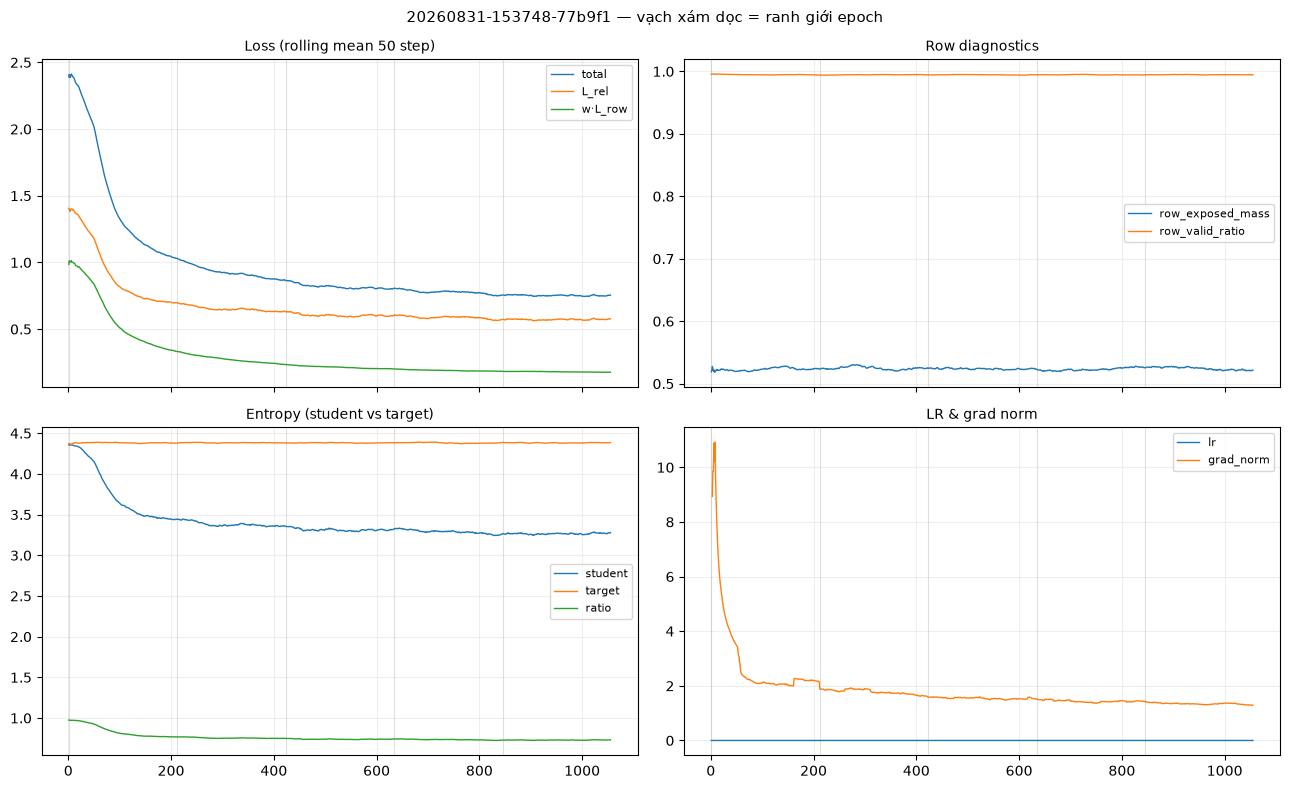

,first,last,mean,drop_in_epoch
epoch,,,,
1,2.3916,1.0535,1.3611,1.3381
2,0.9844,0.8126,0.9090,0.1718
3,0.8699,0.9149,0.8133,-0.0450
4,0.8477,0.7640,0.7718,0.0837
5,0.7838,0.9164,0.7524,-0.1326


In [13]:
# 8. Đồ thị step-level từ step_metrics.jsonl
import matplotlib.pyplot as plt

steps = read_jsonl(RUN_DIR / "step_metrics.jsonl", run_id)
if not steps:
    raise SystemExit("Không có step_metrics.jsonl cho run này.")

df = pd.DataFrame(steps).sort_values("global_step").set_index("global_step")
smooth = lambda s, w=50: s.rolling(w, min_periods=1).mean()

panels = [
    ("Loss (rolling mean 50 step)",
     [("loss", "total"), ("loss_rel", "L_rel"), ("loss_row_weighted", "w·L_row")]),
    ("Row diagnostics",
     [("row_exposed_mass", "row_exposed_mass"), ("row_valid_ratio", "row_valid_ratio")]),
    ("Entropy (student vs target)",
     [("student_entropy", "student"), ("target_entropy", "target"),
      ("student_entropy_ratio", "ratio")]),
    ("LR & grad norm",
     [("lr_next", "lr"), ("grad_norm", "grad_norm")]),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
epoch_starts = df.groupby("epoch").apply(lambda g: g.index.min())
for ax, (title, series) in zip(axes.flat, panels):
    drawn = False
    for col, label in series:
        if col in df.columns and df[col].notna().any():
            ax.plot(smooth(df[col]), label=label, linewidth=1)
            drawn = True
    for e, s in epoch_starts.items():
        ax.axvline(s, color="gray", alpha=0.25, linewidth=0.8)
    ax.set_title(title, fontsize=10)
    if drawn:
        ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
fig.suptitle(f"{run_id} — vạch xám dọc = ranh giới epoch", fontsize=11)
fig.tight_layout()
plt.show()

# Nhìn nhanh: loss step đầu/cuối mỗi epoch, để thấy còn giảm hay đã phẳng
ep_summary = df.groupby("epoch")["loss"].agg(["first", "last", "mean"]).round(4)
ep_summary["drop_in_epoch"] = (ep_summary["first"] - ep_summary["last"]).round(4)
display(ep_summary)


In [14]:
# 9. Calibrate quota → exposure offline từ graph.pt (không cần train)
# Mixture row của mỗi anchor nằm sẵn trong artifact; cumsum theo mass giảm dần
# cho thẳng đường cong "quota k thì exposure bao nhiêu" và trần khi quota→∞.
# Sanity: các mốc đã quan sát trong train log là quota 14 → ~0.44, 24 → ~0.52.
import numpy as np
import torch

art = torch.load(str(cache_dir / "graph.pt"), map_location="cpu")
pool_probs = art["pool_probs"].numpy()                 # (n_scales, n_items, width)
scales = art["metadata"]["diffusion_scales"]
w = np.array([1.0 / r for r in scales]); w /= w.sum()  # omega_r = 1/r, như sampler
mix = (pool_probs * w.reshape(-1, 1, 1)).sum(0)
cum = np.cumsum(-np.sort(-mix, axis=1), axis=1)

ceiling = cum[:, -1]
print(f"Trần exposure (quota→∞, do graph_k + truncation quyết định): "
      f"mean={ceiling.mean():.3f}  p10={np.quantile(ceiling, 0.1):.3f}")
print(f"{'quota':>6} {'mean':>7} {'p10':>7} {'p50':>7} {'p90':>7}")
for q in (14, 24, 34, 44, 64, 90, 128):
    m = cum[:, min(q, cum.shape[1]) - 1]
    print(f"{q:6d} {m.mean():7.3f} {np.quantile(m, 0.1):7.3f} "
          f"{np.quantile(m, 0.5):7.3f} {np.quantile(m, 0.9):7.3f}")

# Quota nhỏ nhất đạt coverage tau cho từng anchor — đọc ngược bảng trên.
for tau in (0.5, 0.6, 0.7, 0.8):
    reached = ceiling >= tau
    need = (cum >= tau).argmax(axis=1) + 1
    need = need[reached]
    print(f"tau={tau}: quota cần p50={np.median(need):.0f}  "
          f"p90={np.quantile(need, 0.9):.0f}  "
          f"({(~reached).mean():.1%} anchor không bao giờ đạt trần này)")


Trần exposure (quota→∞, do graph_k + truncation quyết định): mean=1.000  p10=1.000
 quota    mean     p10     p50     p90
    14   0.620   0.491   0.600   0.835
    24   0.744   0.654   0.722   0.866
    34   0.809   0.728   0.805   0.887
    44   0.846   0.777   0.851   0.907
    64   0.889   0.844   0.887   0.940
    90   0.919   0.886   0.915   0.965
   128   0.944   0.912   0.940   0.983
tau=0.5: quota cần p50=9  p90=15  (0.0% anchor không bao giờ đạt trần này)
tau=0.6: quota cần p50=14  p90=20  (0.0% anchor không bao giờ đạt trần này)
tau=0.7: quota cần p50=22  p90=30  (0.0% anchor không bao giờ đạt trần này)
tau=0.8: quota cần p50=34  p90=50  (0.0% anchor không bao giờ đạt trần này)
